In [1]:

import pandas as pd
import numpy as np


In [4]:
data=pd.read_csv("retraction_watch.csv")
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60040 entries, 0 to 60039
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Record ID              60040 non-null  int64  
 1   Title                  60040 non-null  object 
 2   Subject                60040 non-null  object 
 3   Institution            60039 non-null  object 
 4   Journal                60040 non-null  object 
 5   Publisher              60040 non-null  object 
 6   Country                60040 non-null  object 
 7   Author                 60040 non-null  object 
 8   URLS                   34138 non-null  object 
 9   ArticleType            60040 non-null  object 
 10  RetractionDate         60040 non-null  object 
 11  RetractionDOI          59540 non-null  object 
 12  RetractionPubMedID     54871 non-null  float64
 13  OriginalPaperDate      60040 non-null  object 
 14  OriginalPaperDOI       57502 non-null  object 
 15  Or

In [5]:
data.head()

,Record ID,Title,Subject,Institution,Journal,Publisher,Country,Author,URLS,ArticleType,RetractionDate,RetractionDOI,RetractionPubMedID,OriginalPaperDate,OriginalPaperDOI,OriginalPaperPubMedID,RetractionNature,Reason,Paywalled,Notes
0,60599,Evaluation of the Fluctuation Mechanism of Beh...,(B/T) Business - Economics;(B/T) Computer Scie...,"School of Accounting and Finance, Zhejiang Tec...",International Transactions on Electrical Energ...,Hindawi,China,Xiaoliang Yuan,https://retractionwatch.com/2022/09/28/exclusi...,Research Article;,11/29/2023 0:00,10.1155/2023/9768256,0.0,10/11/2022 0:00,10.1155/2022/2751197,0.0,Retraction,+Fake Peer Review;+Investigation by Journal/Pu...,No,NaN
1,60596,Evaluation Method of Street Green Landscape Vi...,(B/T) Data Science;(B/T) Technology;(B/T) Urba...,"Hualu Engineering & Technology Co., Ltd., Xi’a...",International Transactions on Electrical Energ...,Hindawi,China,Tieming Wang;Mengyu Liu;Wenhua Huang,https://retractionwatch.com/2022/09/28/exclusi...,Research Article;,11/29/2023 0:00,10.1155/2023/9823196,0.0,9/30/2022 0:00,10.1155/2022/2729408,0.0,Retraction,+Fake Peer Review;+Investigation by Journal/Pu...,No,NaN
2,60588,Elevated Substance P Is a Risk Factor for Post...,(BLS) Biology - Molecular;(HSC) Medicine - Neu...,"Department of Joint Sports Medicine, The Affil...",BioMed Research International,Hindawi,China,Wenzheng Zhang;Naixia Hu;Ya Zhang;Anying Wang,https://retractionwatch.com/2022/09/28/exclusi...,Research Article;,11/29/2023 0:00,10.1155/2023/9827945,38075375.0,3/31/2022 0:00,10.1155/2022/5320218,35402619.0,Retraction,+Fake Peer Review;+Investigation by Journal/Pu...,No,NaN
3,60587,Electrophysiological Characteristics of Cervic...,(HSC) Medicine - Neurology;(HSC) Radiology/Ima...,"Department of Electromyography, Zhejiang Unive...",Applied Bionics and Biomechanics,Hindawi,China,Yanrong Wang;Yinping Zhan;Xiaolan Jin;Dandan S...,https://retractionwatch.com/2022/09/28/exclusi...,Research Article;,11/29/2023 0:00,10.1155/2023/9815823,38075149.0,6/26/2022 0:00,10.1155/2022/7522664,35795257.0,Retraction,+Fake Peer Review;+Investigation by Journal/Pu...,No,NaN
4,60586,Electromyography Wearable Device Applied to th...,(B/T) Technology;(HSC) Medicine - Neurology;(H...,"Department of Information Systems, College of ...",Wireless Communications and Mobile Computing,Hindawi,Bangladesh;Iraq;Jordan;Saudi Arabia,Fahima Hajjej;Manal Abdullah Alohali;Malek Has...,https://retractionwatch.com/2022/09/28/exclusi...,Research Article;,11/29/2023 0:00,10.1155/2023/9845719,0.0,8/25/2022 0:00,10.1155/2022/5906815,0.0,Retraction,+Fake Peer Review;+Investigation by Journal/Pu...,No,NaN


#Which country has more retarction

In [6]:

df=data
df["Country"]=df["Country"].str.split(";")
df=df.explode("Country")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72831 entries, 0 to 60039
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Record ID              72831 non-null  int64  
 1   Title                  72831 non-null  object 
 2   Subject                72831 non-null  object 
 3   Institution            72830 non-null  object 
 4   Journal                72831 non-null  object 
 5   Publisher              72831 non-null  object 
 6   Country                72831 non-null  object 
 7   Author                 72831 non-null  object 
 8   URLS                   41106 non-null  object 
 9   ArticleType            72831 non-null  object 
 10  RetractionDate         72831 non-null  object 
 11  RetractionDOI          72272 non-null  object 
 12  RetractionPubMedID     67280 non-null  float64
 13  OriginalPaperDate      72831 non-null  object 
 14  OriginalPaperDOI       70221 non-null  object 
 15  Origina

In [8]:
df["Country"].sample(1)

,Country
3489,China


In [9]:
df1=df["Country"].value_counts().reset_index()
df1.columns=["Country","Count"]
# df1.head()
print("Countries which has Maximum number of retation")
df1.head(10)


Countries which has Maximum number of retation


,Country,Count
0,China,31955
1,United States,6747
2,India,4265
3,Russia,2722
4,United Kingdom,1857
5,Japan,1755
6,Iran,1674
7,Saudi Arabia,1516
8,Germany,1397
9,South Korea,1273


In [10]:
print("China has retraction percentage globaly")
int(df1.loc[0,"Count"].sum()  / df1.Count.sum() *100)

China has retraction percentage globaly


43

In [11]:
df1.Count.head(10).sum()  / df1.Count.sum() *100

np.float64(75.73835317378588)

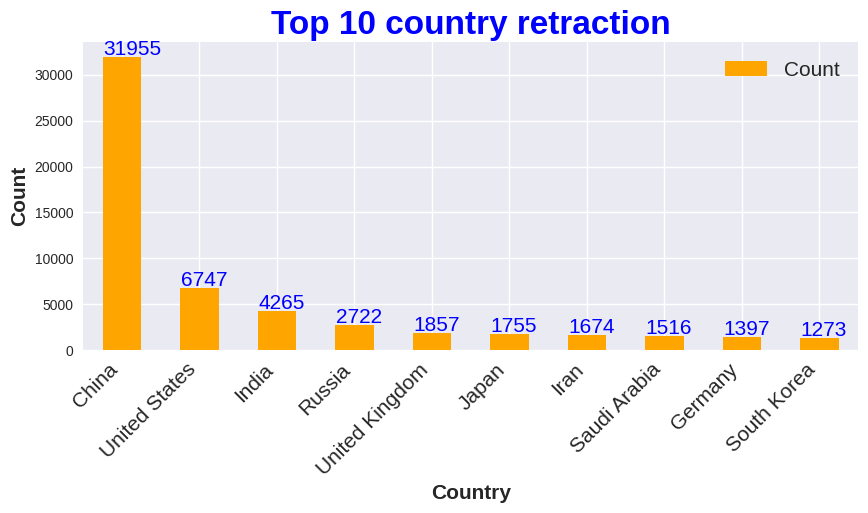

In [17]:

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

df1.head(10).plot(kind="bar",x="Country",y="Count",figsize=(10,4),color="Orange",label="Count")
plt.xticks(rotation=45,ha="right",fontsize=15)
plt.legend(loc="best",edgecolor="black",fontsize=15)
for i in range(10):
  plt.text(i-0.24,df1.iloc[i,1]+250,str(df1.iloc[i,1]),color="blue",fontsize=15)

plt.title("Top 10 country retraction",fontsize=24,weight="bold",color="blue")
plt.xlabel("Country",fontsize=15,weight="bold")
plt.ylabel("Count",fontsize=15,weight="bold")

plt.show()

In [18]:
print("Countries which has Minimum number of retration")
df1.tail(10)

Countries which has Minimum number of retration


,Country,Count
172,Cook Islands,1
173,Paraguay,1
174,Guyana,1
175,Jamaica,1
176,East Timor,1
177,Dominican Republic,1
178,Gaza Strip,1
179,Sierra Leone,1
180,Mauritius,1
181,Cayman Islands,1


#Which subject has the most and least retractions

In [19]:
df.Subject[0]

'(B/T) Business - Economics;(B/T) Computer Science;(B/T) Data Science;(B/T) Technology;'

In [20]:
# (B/T) Business - Economics;(B/T) Computer Science;(B/T) Data Science;(B/T) Technology;

In [24]:
df2=data
df2["subject"]=df2['Subject'].str.replace("(B/T)","")
df2["subject"]=df2["subject"].str.split(";")
df2=df2.explode("subject")
df2_count=df2["subject"].value_counts().reset_index()
df2_count.columns=["subject","count"]

In [35]:
df2_count.head(5)

,subject,count
0,,60040
1,(BLS) Biology - Cellular,11358
2,Technology,9643
3,(BLS) Genetics,7818
4,(BLS) Biochemistry,7417


In [36]:
df2_count.iloc[:,1].sum()

np.int64(219865)

In [37]:
df2_count.loc[0,"count"] / df2_count.iloc[:,1].sum() *100

np.float64(27.30766606781434)

In [38]:
print (f"The Subject {df2_count.iloc[1,0]} has {df2_count.iloc[1,1]} Retrations ,\n That is Maximum Retaction")


The Subject (BLS) Biology - Cellular has 11358 Retrations ,
 That is Maximum Retaction


In [39]:
df2_count.tail(5)

,subject,count
126,(HUM) History - Africa,11
127,(HUM) History - South America,7
128,(HUM) History - United States,7
129,(PHY) Forensic Sciences,5
130,(HUM) History - Australia,1


In [40]:
print (f"The Subject {df2_count.iloc[-1,0]} has {df2_count.iloc[-1,1]} Retractions ,\n That is Minimum Retaction")

The Subject (HUM) History - Australia has 1 Retractions ,
 That is Minimum Retaction


In [41]:
df2_count.describe()

,count
count,131.000000
mean,1678.358779
std,5456.651523
min,1.000000
25%,206.000000
50%,630.000000
75%,1301.000000
max,60040.000000


In [42]:
df2_count[df2_count["subject"]!=""].describe()

,count
count,130.000000
mean,1229.423077
std,1843.644372
min,1.000000
25%,202.500000
50%,627.500000
75%,1285.750000
max,11358.000000


In [43]:
#known subject  (percentage of top 4)
df2_count[df2_count["subject"]!=""].iloc[0:4,1].sum() / df2_count[df2_count["subject"]!=""].iloc[:,1].sum()  *100

np.float64(22.67229782574691)

 #**Which institute has more retraction**

In [45]:
# data.head(2)
data["Institution"][65]

'School of Computer Science, Civil Aviation Flight University of China, Guanghan 618307, China; Shaoxing University Yuanpei College, Shaoxing 312000, China;'

In [46]:
#thire is multiple institues divided by ;
df3=data
df3["Institution"]=df3["Institution"].str.split(";")
df3=df3.explode("Institution")

In [47]:
df3_count=df3["Institution"].value_counts().reset_index()

In [48]:
df3_count.head(10)

,Institution,count
0,,41723
1,Unknown,398
2,unavailable,291
3,Unavailable,140
4,"Department of Anesthesiology, Showa University...",101
5,"College of Medicine, Imam Abdulrahman Bin Fai...",78
6,"Praxis für Anästhesie, Heidelberg",60
7,"Klinik für Anästhesiologie, Universitätsklini...",60
8,Klinik für Anästhesiologie und Intensivmedizi...,60
9,"Special Infectious Agents Unit, King Fahd Med...",52


In [49]:
#institute they dost mention their name
df3_count.iloc[:4,1].sum()  / df3_count.iloc[:,1].sum() *100

np.float64(24.454048089743)

In [50]:
#5 has more retraction papers
print (f"The Institute {df3_count.iloc[4,0]} has {df2_count.iloc[4,1]} Retractions ,\n That is Maximum Retaction")

The Institute Department of Anesthesiology, Showa University Hospital, Tokyo, Japan has 7417 Retractions ,
 That is Maximum Retaction


In [ ]:
df3_count[df3_count["count"]==1].count()

,0
Institution,97683
count,97683


In [51]:
df3_count.shape

(110226, 2)

In [52]:
print("their are 97683 institute has retation only 1")

their are 97683 institute has retation only 1


#which publisher have more retraction


In [54]:
data.Publisher[0]

'Hindawi'

In [55]:
df4=data
df4_count=df4["Publisher"].value_counts().reset_index()

In [ ]:
df4_count.head(5)

,Publisher,count
0,Hindawi,10114
1,IEEE: Institute of Electrical and Electronics ...,10092
2,Elsevier,6410
3,Springer,5038
4,Wiley,3220


In [56]:
print(f"The Publisher {df4_count.iloc[0,0]}has more Retraction : {df4_count.iloc[0,1]} Retractions")
print(f"The Publisher {df4_count.iloc[1,0]} Also has more Retraction : {df4_count.iloc[1,1]} Retractions")



The Publisher Hindawihas more Retraction : 10114 Retractions
The Publisher IEEE: Institute of Electrical and Electronics Engineers Also has more Retraction : 10092 Retractions


#Which articles are most retracted

In [57]:
article=data.ArticleType.value_counts().reset_index()
article.columns=["ArticleType","Count"]
article.head(5)

,ArticleType,Count
0,Research Article;,38783
1,Conference Abstract/Paper;,12800
2,Clinical Study;,2595
3,Review Article;,1905
4,Case Report;,628


In [58]:
print(f"The ArticleType {article.iloc[0,0]} has More ( {article.iloc[0,1]} ) Retractions")

The ArticleType Research Article; has More ( 38783 ) Retractions


#find the reason for most restaction


In [59]:
data.Reason[0]

'+Fake Peer Review;+Investigation by Journal/Publisher;+Investigation by Third Party;+Paper Mill;+Unreliable Results;'

In [60]:
df5=data
df5["Reason"]=df5["Reason"].str.split(";")
df5=df5.explode("Reason")
df5_Count=df5["Reason"].value_counts().reset_index()
df5_Count.columns=["Reason","Count"]
df5_Count.head(10)


,Reason,Count
0,,60040
1,+Investigation by Journal/Publisher,21663
2,+Unreliable Results,14923
3,+Concerns/Issues About Data,13053
4,+Investigation by Third Party,12983
5,+Notice - Limited or No Information,12032
6,+Concerns/Issues about Referencing/Attributions,9657
7,+Paper Mill,8990
8,+Concerns/Issues with Peer Review,8448
9,+Concerns/Issues About Results,7855


In [61]:
reason=df5_Count.iloc[1:11,:]

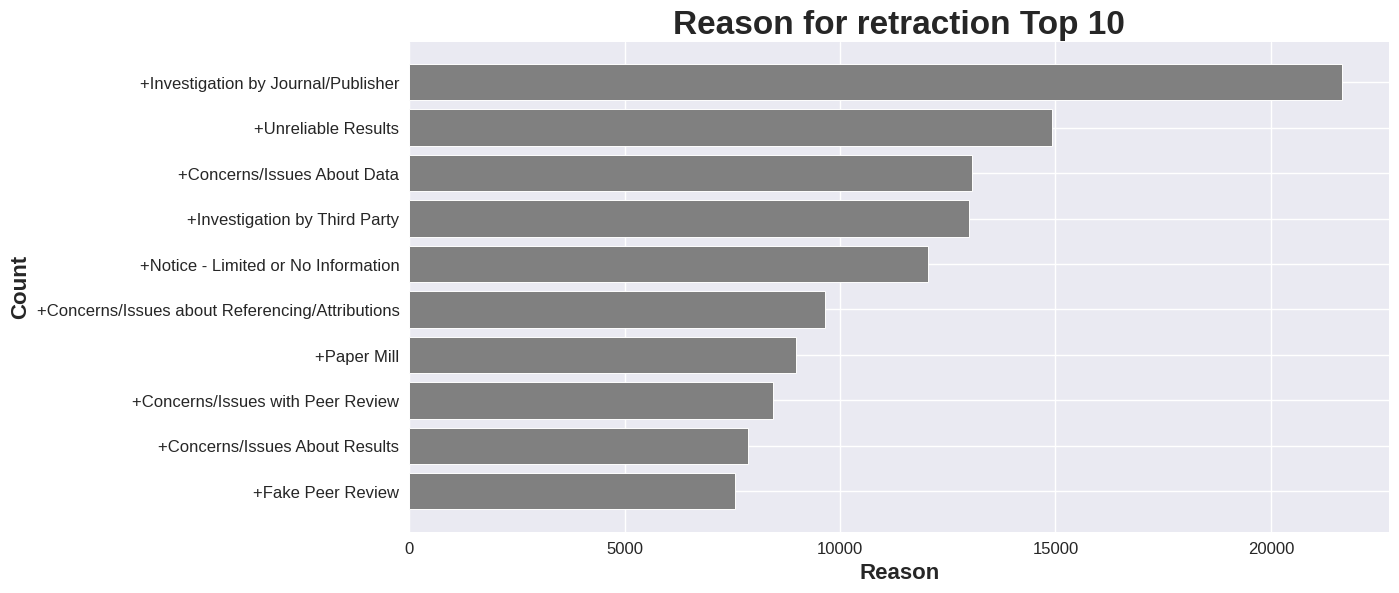

In [63]:
from matplotlib import collections
#using matplotlib
import matplotlib.pyplot as plt
plt.style.use('_mpl-gallery')

fig,ax=plt.subplots(figsize=(10,5))

plt.barh(reason["Reason"],reason["Count"],edgecolor="white", linewidth=0.7,color="gray")
#reverse
plt.gca().invert_yaxis()
plt.xticks(fontsize=12)
plt.yticks(rotation=0, ha="right",fontsize=12) # Rotate x-axis labels for readability
plt.xlabel("Reason",fontsize=16,weight="bold")
plt.ylabel("Count",fontsize=16,weight="bold")

plt.title("Reason for retraction Top 10",
          fontsize=24
          ,weight="bold")
plt.show()

#Filter only India from country

1.  Which subject has the most and least retractions
2.  Which institute has more retraction
3.  Which publisher has more retraction
4.  Which articles are most retracted
5.  Find the reasons for most retraction

In [64]:
#country wise exploted data
df["Country"].sample(1)


,Country
36137,France


In [65]:
df[df["Country"]=="India"].sample(2)

,Record ID,Title,Subject,Institution,Journal,Publisher,Country,Author,URLS,ArticleType,RetractionDate,RetractionDOI,RetractionPubMedID,OriginalPaperDate,OriginalPaperDOI,OriginalPaperPubMedID,RetractionNature,Reason,Paywalled,Notes
24519,35801,An Automated Machine Learning Approach for Str...,(B/T) Computer Science;(HSC) Medicine - Neurol...,Department of Computer Science and Engineering...,Journal of Physics: Conference Series,IOP Publishing,India,N Pooranam;T A Dhivya;R Punitha;S Preethi,https://retractionwatch.com/2022/02/23/publish...,Conference Abstract/Paper;,2/23/2022 0:00,10.1088/1742-6596/1916/1/012325,0.0,3/25/2021 0:00,10.1088/1742-6596/1916/1/012085,0.0,Retraction,+Concerns/Issues about Referencing/Attribution...,No,NaN
56582,3540,Changes of Splanchnic Perfusion After Applying...,(BLS) Biology - General;(HSC) Medicine - Cardi...,"Department of Anesthesiology, Intensive Care U...",Indian Journal of Critical Care Medicine: Peer...,Wolters Kluwer,India,Suman Sarkar;Prithwis Bhattacharya;Indrajit Ku...,NaN,Clinical Study;,10/8/2012 0:00,NaN,23188952.0,7/1/2009 0:00,10.4103/0972-5229.53109,19881173.0,Retraction,+Plagiarism of Text;,No,NaN


In [101]:
Idf=df[df["Country"]=="India"].copy()

# Which subject has the most and least retractions

In [109]:
#explode subject of idf
Idf1=Idf.copy()
Idf1["Subject"].sample(2)


,Subject
57896,(BLS) Genetics;(BLS) Plant Biology/Botany;
4449,(BLS) Biochemistry;(BLS) Biology - Cellular;(B...


In [110]:
Idf1["Subject"]=Idf1["Subject"].str.split(";")
Idf1=Idf1.explode("Subject")
Idf1_Count=Idf1["Subject"].value_counts().reset_index()
Idf1_Count.columns=["Subject","Count"]

In [111]:
Idf1["Subject"].sample(2)

,Subject
42321,(PHY) Materials Science
17367,(B/T) Technology


In [112]:
Idf1_Count.head(5)


,Subject,Count
0,,4265
1,(B/T) Computer Science,1178
2,(B/T) Technology,904
3,(BLS) Biochemistry,552
4,(PHY) Materials Science,480


In [113]:
Idf1_Count.tail(5)

,Subject,Count
116,(HUM) Journalism,1
117,(HUM) History - United States,1
118,(BLS) Forensic Sciences,1
119,(HUM) Cartography,1
120,(HUM) Philosophy,1


###IMPORTENT NOTE
their are many Paper which dont have a subject name ,its seems like something is wrong in paper publication  and paper approval
its is nessecory that
Indian govt should be awaire of this


##
*  indian research is mejorly focous on Coumputer_science,technoly, biochemistry and matirial science
*  indian govrment should give good plotform for research (mainly guidence is importent)
*  And also focous on subject like jurnalish,forensic science,histry these have less retraction (mean less compitaion thire ) ,we have to ecourage those subject reasercher by giving scholrship ect



In [114]:
print(f"The Subject {Idf1_Count.iloc[1,0]} has More Retraction {Idf1_Count.iloc[1,1]}")
print(f"The Subject {Idf1_Count.iloc[-1,0]} has Less Retraction {Idf1_Count.iloc[-1,1]}")

The Subject (B/T) Computer Science has More Retraction 1178
The Subject (HUM) Philosophy has Less Retraction 1


In [115]:
print(f"Total number of restration from india : {Idf1_Count['Count'].sum()}")

Total number of restration from india : 14965


In [116]:
r_subject=Idf1_Count.iloc[1:5,1].sum()
r_subject

np.int64(3114)

In [117]:
Known_retactions=Idf1_Count['Count'].sum() -Idf1_Count.iloc[0,1]
percentage_of_Top_four=(r_subject/Known_retactions)*100

In [118]:
print(f"the Subjects \n{Idf1_Count.iloc[1:5,0]}\n More retraction ,\n bcz the above subject have {percentage_of_Top_four}% out of total known indian retracions\n we have to improve here")

the Subjects 
1     (B/T) Computer Science
2           (B/T) Technology
3         (BLS) Biochemistry
4    (PHY) Materials Science
Name: Subject, dtype: object
 More retraction ,
 bcz the above subject have 29.102803738317757% out of total known indian retracions
 we have to improve here


##the Subjects
1.     (B/T) Computer Science
2.     (B/T) Technology
3.     (BLS) Biochemistry
4.     (PHY) Materials Science
 these above Subject are More retraction ,becouse thet are 29.102803738317757% out of total known indian retracions
 we have to improve here

# Which institute has more retraction

In [119]:
Idf2=Idf.copy()

Idf2["Institution"].iloc[1]
#

'Department of Computer Engineering & Applications, GLA University Mathura, Mathura-281406, India; Department of Computer Science and Engineering, ABES Engineering College Ghaziabad, India; Department of Computer Science & Engineering, School of Engineering & Technology Sharda University, Grater Noida, India; Computer Science and Information Technology (CSIT), College of Engineering, Abu Dhabi University, P.O. Box 5991, Abu Dhabi, UAE; Department of Information Systems, College of Computer and Information Science, Princess Nourah Bint Abdulrahman University, P.O. Box 84428, Riyadh 11671, Saudi Arabia; LBEF Campus, Kathmandu, Nepal;'

In [78]:
Idf2["Institution"]=Idf2["Institution"].str.split(";")
Idf2=Idf2.explode("Institution")
Idf2_count=Idf2["Institution"].value_counts().reset_index()
Idf2_count.columns=["Institution","Count"]


In [79]:
Idf2_count.head(5)

,Institution,Count
0,,2739
1,Department of Computer Science and Engineering...,16
2,"Anna University, Chennai, India",16
3,"Department of Civil Engineering, Ambo Univers...",16
4,"Department of Chemical Engineering, College o...",15


In [80]:
below_5=(Idf2_count[Idf2_count["Count"]<5]).iloc[:,-1].sum()
below_5

np.int64(12041)

In [81]:
sum=Idf2_count["Count"].sum()
print("total papers :",sum)
print("percentage :",(Idf2_count.iloc[0, 1] / sum) *100)

total papers : 15222
percentage : 17.993693338588884


###WARNING TO INDIA EDUCTION SYSYTEM
See thire are 2739 papers that is 18 percentage of our indian paper retaction
which mean without institute name thire are many paper have retraction so we have to find those institute and
we work on the improvement of those institute



3.   Which publisher has more retraction

In [120]:
Idf3=Idf.copy()

In [121]:
Idf3["Publisher"].sample(5)

,Publisher
24683,IOP Publishing
38463,Springer
24165,IOP Publishing
20793,Elsevier
27635,Taylor and Francis


In [122]:
Idf3["Publisher"].value_counts().describe()

,count
count,199.000000
mean,21.432161
std,89.719846
min,1.000000
25%,1.000000
50%,1.000000
75%,2.500000
max,725.000000


In [123]:
#no need of split
Idf3_count=Idf3["Publisher"].value_counts().reset_index()
Idf3_count.columns=["Publisher","Count"]
Idf3_count.head(5)


,Publisher,Count
0,Springer,725
1,Hindawi,632
2,Elsevier,553
3,IOP Publishing,461
4,Springer - Nature Publishing Group,326


In [124]:
print(f"The {Idf3_count.iloc[0,0]} has More Retations papers , That is {Idf3_count.iloc[0,1]} Retactions")

The Springer has More Retations papers , That is 725 Retactions


In [125]:
print(f"The {Idf3_count.iloc[-1,0]} has Less Retations papers , That is {Idf3_count.iloc[-1,1]} Retactions")

The Wiley-Blackwell has Less Retations papers , That is 1 Retactions


4.  Which articles are most retracted


In [126]:
Idf4=Idf.copy()

In [127]:
Idf4["ArticleType"].sample(5)

,ArticleType
22061,Research Article;
22262,Research Article;
58050,Research Article;
55136,Clinical Study;
37272,Research Article;


In [128]:
#split
Idf4["ArticleType"]=Idf4["ArticleType"].str.split(";")
Idf4=Idf4.explode("ArticleType")
Idf4_count=Idf4["ArticleType"].value_counts().reset_index()

In [129]:
Idf4_count.columns=["ArticleType","Count"]
Idf4_count.head(5)

,ArticleType,Count
0,,4265
1,Research Article,3194
2,Conference Abstract/Paper,613
3,Review Article,224
4,Clinical Study,114


In [130]:
print(f"The Article Type :{Idf4_count.iloc[1,0]} has More Retraction :{Idf4_count.iloc[1,1]}")
print(f"The Article Type :{Idf4_count.iloc[-1,0]} has Less Retraction :{Idf4_count.iloc[-1,1]}")

The Article Type :Research Article has More Retraction :3194
The Article Type :Guideline has Less Retraction :1


#Note
there are 4265 retraction doesnt have mentioned the which type of Article they are

5.  Find the reasons for most retraction

In [140]:
Idf4=Idf.copy()

In [141]:
Idf4.Reason.head()

,Reason
59,"[+Fake Peer Review, +Investigation by Journal/..."
64,"[+Fake Peer Review, +Investigation by Journal/..."
66,"[+Fake Peer Review, +Investigation by Journal/..."
81,"[+Fake Peer Review, +Investigation by Journal/..."
86,"[+Fake Peer Review, +Investigation by Journal/..."


In [142]:
#split
Idf4["Reason"]=Idf4["Reason"].str.split(";")
Idf4=Idf4.explode("Reason")

Idf4.Reason.sample(2)

,Reason
21948,+Fake Peer Review
41182,+Removed


In [143]:
Idf4_count=Idf4.Reason.value_counts().reset_index()
Idf4_count.columns=["Reason","Count"]
Idf4_count.head(5)

,Reason,Count
0,,4265
1,+Investigation by Journal/Publisher,2153
2,+Fake Peer Review,1440
3,+Unreliable Results,1183
4,+Investigation by Third Party,1072


In [146]:

first4=Idf4_count.iloc[1:5,-1].sum()
Idf4_count[Idf4_count["Count"]==1].count()

,0
Reason,6
Count,6


In [147]:
print(f"There are 4265 retraction dont have reson for retraction ,\n exept these,\n{first4} papers are retracted bcz of the\n{Idf4_count.iloc[1:5,0]}")

There are 4265 retraction dont have reson for retraction ,
 exept these,
5848 papers are retracted bcz of the
1    +Investigation by Journal/Publisher
2                      +Fake Peer Review
3                    +Unreliable Results
4          +Investigation by Third Party
Name: Reason, dtype: object


There are **4265** retraction dont have reson for retraction ,
 exept these,
**5848** papers are retracted bcz of the
1.    +Investigation by Journal/Publisher
2.    +Fake Peer Review
3.    +Unreliable Results
4.    +Investigation by Third Party

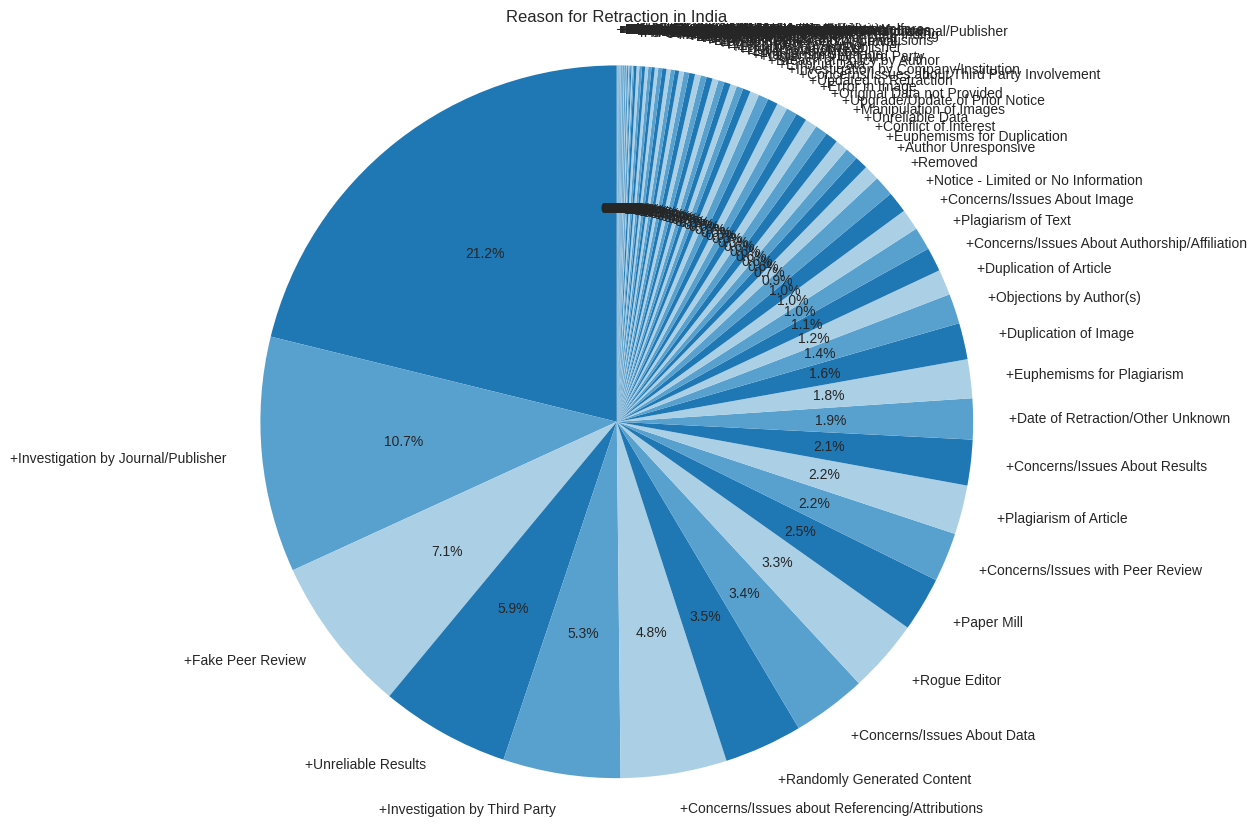

In [148]:
#pie chart
plt.figure(figsize=(10, 8))
plt.pie(Idf4_count["Count"], labels=Idf4_count["Reason"], autopct='%1.1f%%', startangle=90)
plt.title("Reason for Retraction in India")
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

50% of the Retration is due to


1.   Investigation by Journal/Publisher
2.   Fake Peer Review
3.   Unreliable Results
4.   Investigation by Third Party



#New  for india only

## 1.How Retraction depends on paywalled(yes/no)
how type of articles , subject ,publisher depends on paywalled

##2. which type of article has more retraction time
##3. based of subject how retraction time related
##4. based on publisher how retraction time related
##5. based on retraction type how retraction time related





In [149]:
# 1.How Retraction depends on paywalled(yes/no)
Idf.head(1)

,Record ID,Title,Subject,Institution,Journal,Publisher,Country,Author,URLS,ArticleType,RetractionDate,RetractionDOI,RetractionPubMedID,OriginalPaperDate,OriginalPaperDOI,OriginalPaperPubMedID,RetractionNature,Reason,Paywalled,Notes
59,60529,Detecting and Extracting Brain Hemorrhages fro...,(B/T) Technology;(HSC) Medicine - Cardiovascul...,"School of Computing Science and Engineering, V...",Computational Intelligence and Neuroscience,Hindawi,India,V Pandimurugan;S Rajasoundaran;Sidheswar Routr...,https://retractionwatch.com/2022/09/28/exclusi...,Research Article;,11/29/2023 0:00,10.1155/2023/9763965,38074381.0,5/6/2022 0:00,10.1155/2022/6671234,35571726.0,Retraction,"[+Fake Peer Review, +Investigation by Journal/...",No,NaN


In [150]:
Idf.Country.value_counts()

,count
Country,
India,4265


In [151]:
Idf.Paywalled.value_counts()

,count
Paywalled,
No,4187
Yes,66
Unknown,12


In [152]:
Idfp=Idf[Idf["Paywalled"]!="Unknown"]

In [153]:
Idfp.Paywalled.value_counts()

,count
Paywalled,
No,4187
Yes,66


Text(0, 0.5, 'RetractionNature')

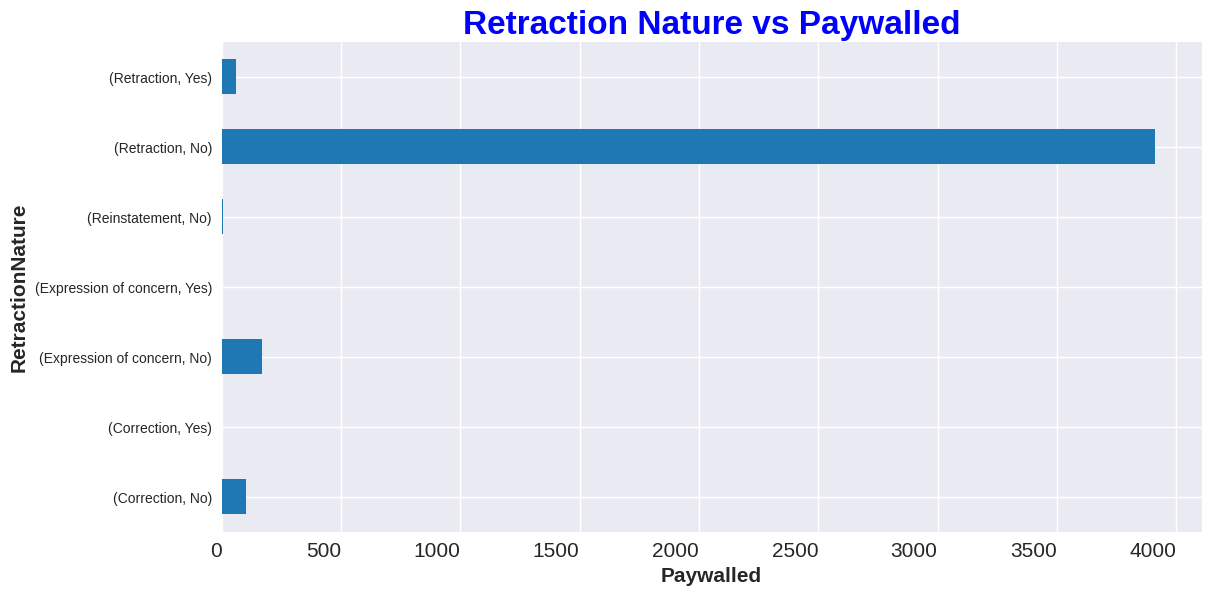

In [154]:
Idfp.groupby("RetractionNature")["Paywalled"].value_counts().plot(kind="barh",figsize=(10,5))
plt.xticks(ha="right",fontsize=15)
plt.title("Retraction Nature vs Paywalled",fontsize=24,weight="bold",color="blue")
plt.xlabel("Paywalled",fontsize=15,weight="bold")
plt.ylabel("RetractionNature",fontsize=15,weight="bold")


##Here we can understand that most of all retractions are free
---
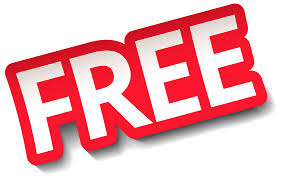


In [155]:
Idf.columns

Index(['Record ID', 'Title', 'Subject', 'Institution', 'Journal', 'Publisher',
       'Country', 'Author', 'URLS', 'ArticleType', 'RetractionDate',
       'RetractionDOI', 'RetractionPubMedID', 'OriginalPaperDate',
       'OriginalPaperDOI', 'OriginalPaperPubMedID', 'RetractionNature',
       'Reason', 'Paywalled', 'Notes'],
      dtype='object')

#2. which type of article has more retraction time

In [156]:
#creat retraction time
Idf.loc[:, "RetractionDate"] = pd.to_datetime(Idf["RetractionDate"])
Idf.loc[:, "OriginalPaperDate"] = pd.to_datetime(Idf["OriginalPaperDate"])

Idf.loc[:, "RetractionTime"] = (
    Idf["RetractionDate"] - Idf["OriginalPaperDate"]
)

In [157]:
Idf["RetractionTime"].describe()


/tmp/ipykernel_1874/2129354349.py:1: FutureWarning:

The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`



,RetractionTime
count,4265
unique,1753
top,335 days 00:00:00
freq,348


In [158]:
Idf.ArticleType.value_counts().sample()

,count
ArticleType,
Review Article;,207


In [159]:
IdfT=Idf

In [160]:
IdfT.head(1)

,Record ID,Title,Subject,Institution,Journal,Publisher,Country,Author,URLS,ArticleType,...,RetractionDOI,RetractionPubMedID,OriginalPaperDate,OriginalPaperDOI,OriginalPaperPubMedID,RetractionNature,Reason,Paywalled,Notes,RetractionTime
59,60529,Detecting and Extracting Brain Hemorrhages fro...,(B/T) Technology;(HSC) Medicine - Cardiovascul...,"School of Computing Science and Engineering, V...",Computational Intelligence and Neuroscience,Hindawi,India,V Pandimurugan;S Rajasoundaran;Sidheswar Routr...,https://retractionwatch.com/2022/09/28/exclusi...,Research Article;,...,10.1155/2023/9763965,38074381.0,2022-05-06 00:00:00,10.1155/2022/6671234,35571726.0,Retraction,"[+Fake Peer Review, +Investigation by Journal/...",No,NaN,572 days 00:00:00


In [161]:
IdfT=IdfT.explode("ArticleType")

IdfT.ArticleType.head(10)

,ArticleType
59,Research Article;
64,Research Article;
66,Research Article;
81,Research Article;
86,Research Article;
110,Research Article;
118,Research Article;
122,Research Article;
128,Research Article;
185,Research Article;


In [162]:
IdfT=IdfT[["ArticleType","RetractionTime"]]

In [163]:
IdfT = IdfT.loc[IdfT["ArticleType"].str.strip() != ""].reset_index()

In [164]:
IdfT.drop(columns="index",inplace=True)

In [165]:
IdfT.head()

,ArticleType,RetractionTime
0,Research Article;,572 days 00:00:00
1,Research Article;,522 days 00:00:00
2,Research Article;,645 days 00:00:00
3,Research Article;,376 days 00:00:00
4,Research Article;,713 days 00:00:00


In [166]:
IdfT.groupby("ArticleType")["RetractionTime"].mean().sort_values(ascending=False)

,RetractionTime
ArticleType,
Correction/Erratum/Corrigendum;,3125 days 00:00:00
Case Report;Research Article;,2365 days 00:00:00
Retraction Notice;,1936 days 00:00:00
Review Article;Revision;,1663 days 17:08:34.285714288
Correction/Erratum/Corrigendum;Research Article;,1436 days 00:00:00
Retracted Article;Retraction Notice;,1392 days 00:00:00
Research Article;Retraction Notice;,1166 days 00:00:00
Review Article;,1068 days 12:17:23.478260864
Research Article;,1006 days 21:43:13.795970576


In [167]:
#convert day to numbers
# Ensure the column is Timedelta type before extracting days

IdfT["RetractionTime"]=pd.to_timedelta(IdfT["RetractionTime"]).dt.days


In [168]:
IdfT.head()

,ArticleType,RetractionTime
0,Research Article;,572
1,Research Article;,522
2,Research Article;,645
3,Research Article;,376
4,Research Article;,713


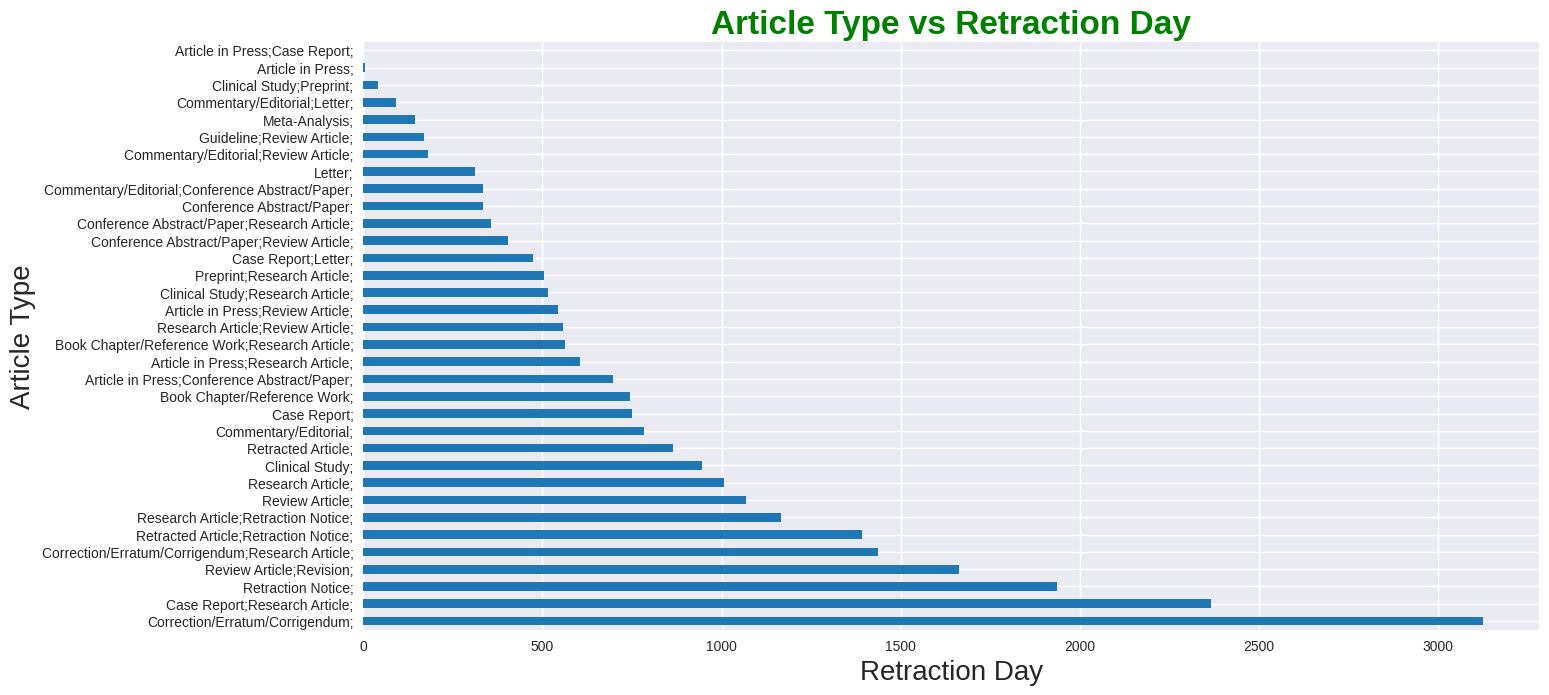

In [169]:
IdfT.groupby("ArticleType")["RetractionTime"].mean().sort_values(ascending=False).plot(kind="barh",figsize=(12,6))
plt.title("Article Type vs Retraction Day",fontsize=24,weight="bold",color="Green")
plt.xlabel("Retraction Day",fontsize=20)
plt.ylabel("Article Type",fontsize=20)
plt.show()

3. based of subject how retraction time related
4. based on publisher how retraction time related
5. based on retraction type how retraction time related

In [170]:
Idf["RetractionTime"]=pd.to_timedelta(Idf["RetractionTime"]).dt.days

In [171]:
Idf.head(1)

,Record ID,Title,Subject,Institution,Journal,Publisher,Country,Author,URLS,ArticleType,...,RetractionDOI,RetractionPubMedID,OriginalPaperDate,OriginalPaperDOI,OriginalPaperPubMedID,RetractionNature,Reason,Paywalled,Notes,RetractionTime
59,60529,Detecting and Extracting Brain Hemorrhages fro...,(B/T) Technology;(HSC) Medicine - Cardiovascul...,"School of Computing Science and Engineering, V...",Computational Intelligence and Neuroscience,Hindawi,India,V Pandimurugan;S Rajasoundaran;Sidheswar Routr...,https://retractionwatch.com/2022/09/28/exclusi...,Research Article;,...,10.1155/2023/9763965,38074381.0,2022-05-06 00:00:00,10.1155/2022/6671234,35571726.0,Retraction,"[+Fake Peer Review, +Investigation by Journal/...",No,NaN,572


In [172]:
IdfS=Idf
IdfS["Subject"]=IdfS["Subject"].str.split(";")
IdfS=IdfS.explode("Subject")
IdfS["Subject"]=IdfS["Subject"].str.strip()


In [173]:
IdfP=Idf #for Publisher
IdfRT=Idf #for retation types

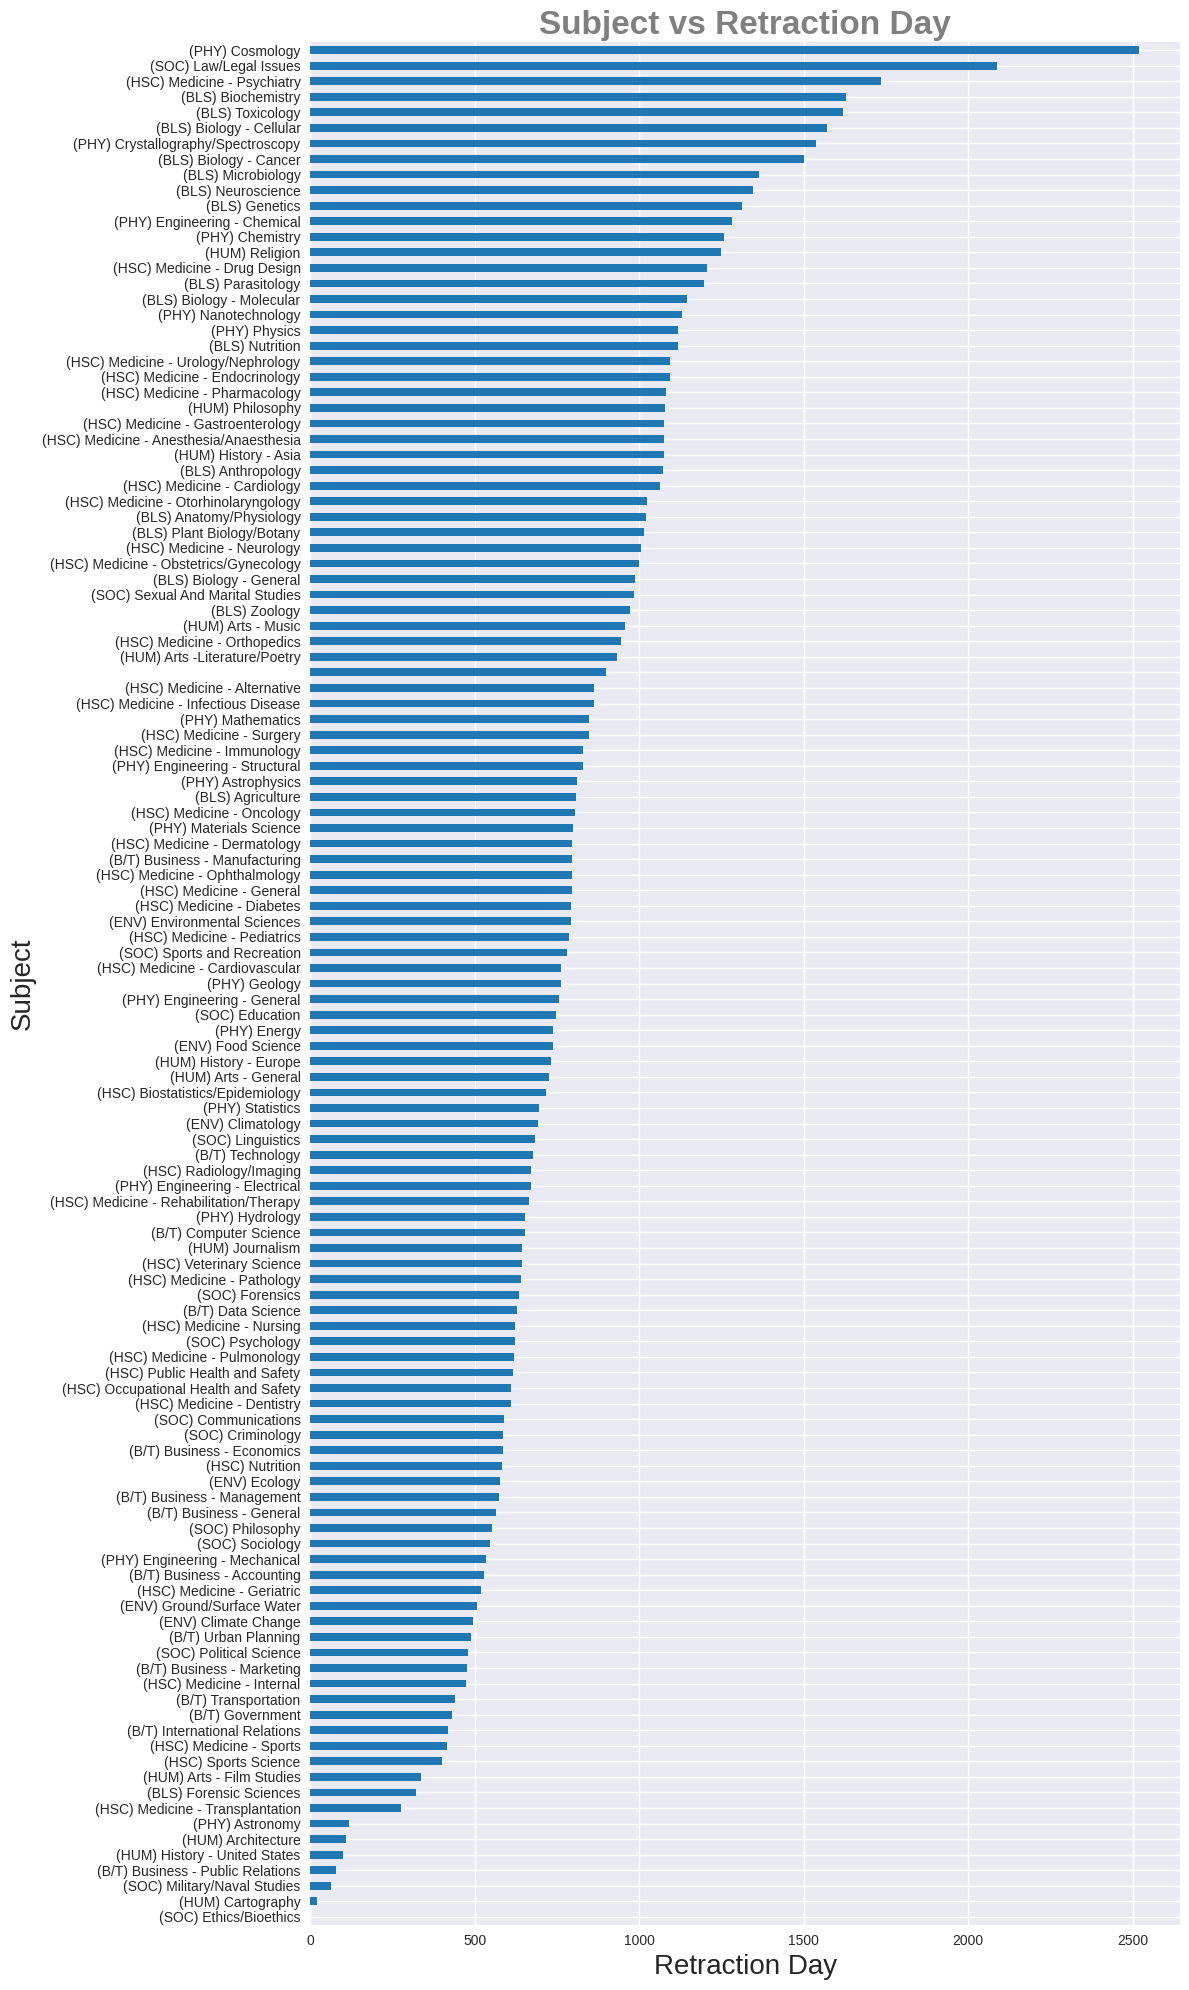

In [174]:
IdfS.groupby("Subject")["RetractionTime"].mean().sort_values().plot(kind="barh",figsize=(12,20))
plt.title("Subject vs Retraction Day",fontsize=24,weight="bold",color="Gray")
plt.yticks(rotation=0,fontsize=10)
plt.ylabel("Subject",fontsize=20)
plt.xlabel("Retraction Day",fontsize=20)
plt.tight_layout()
plt.show()


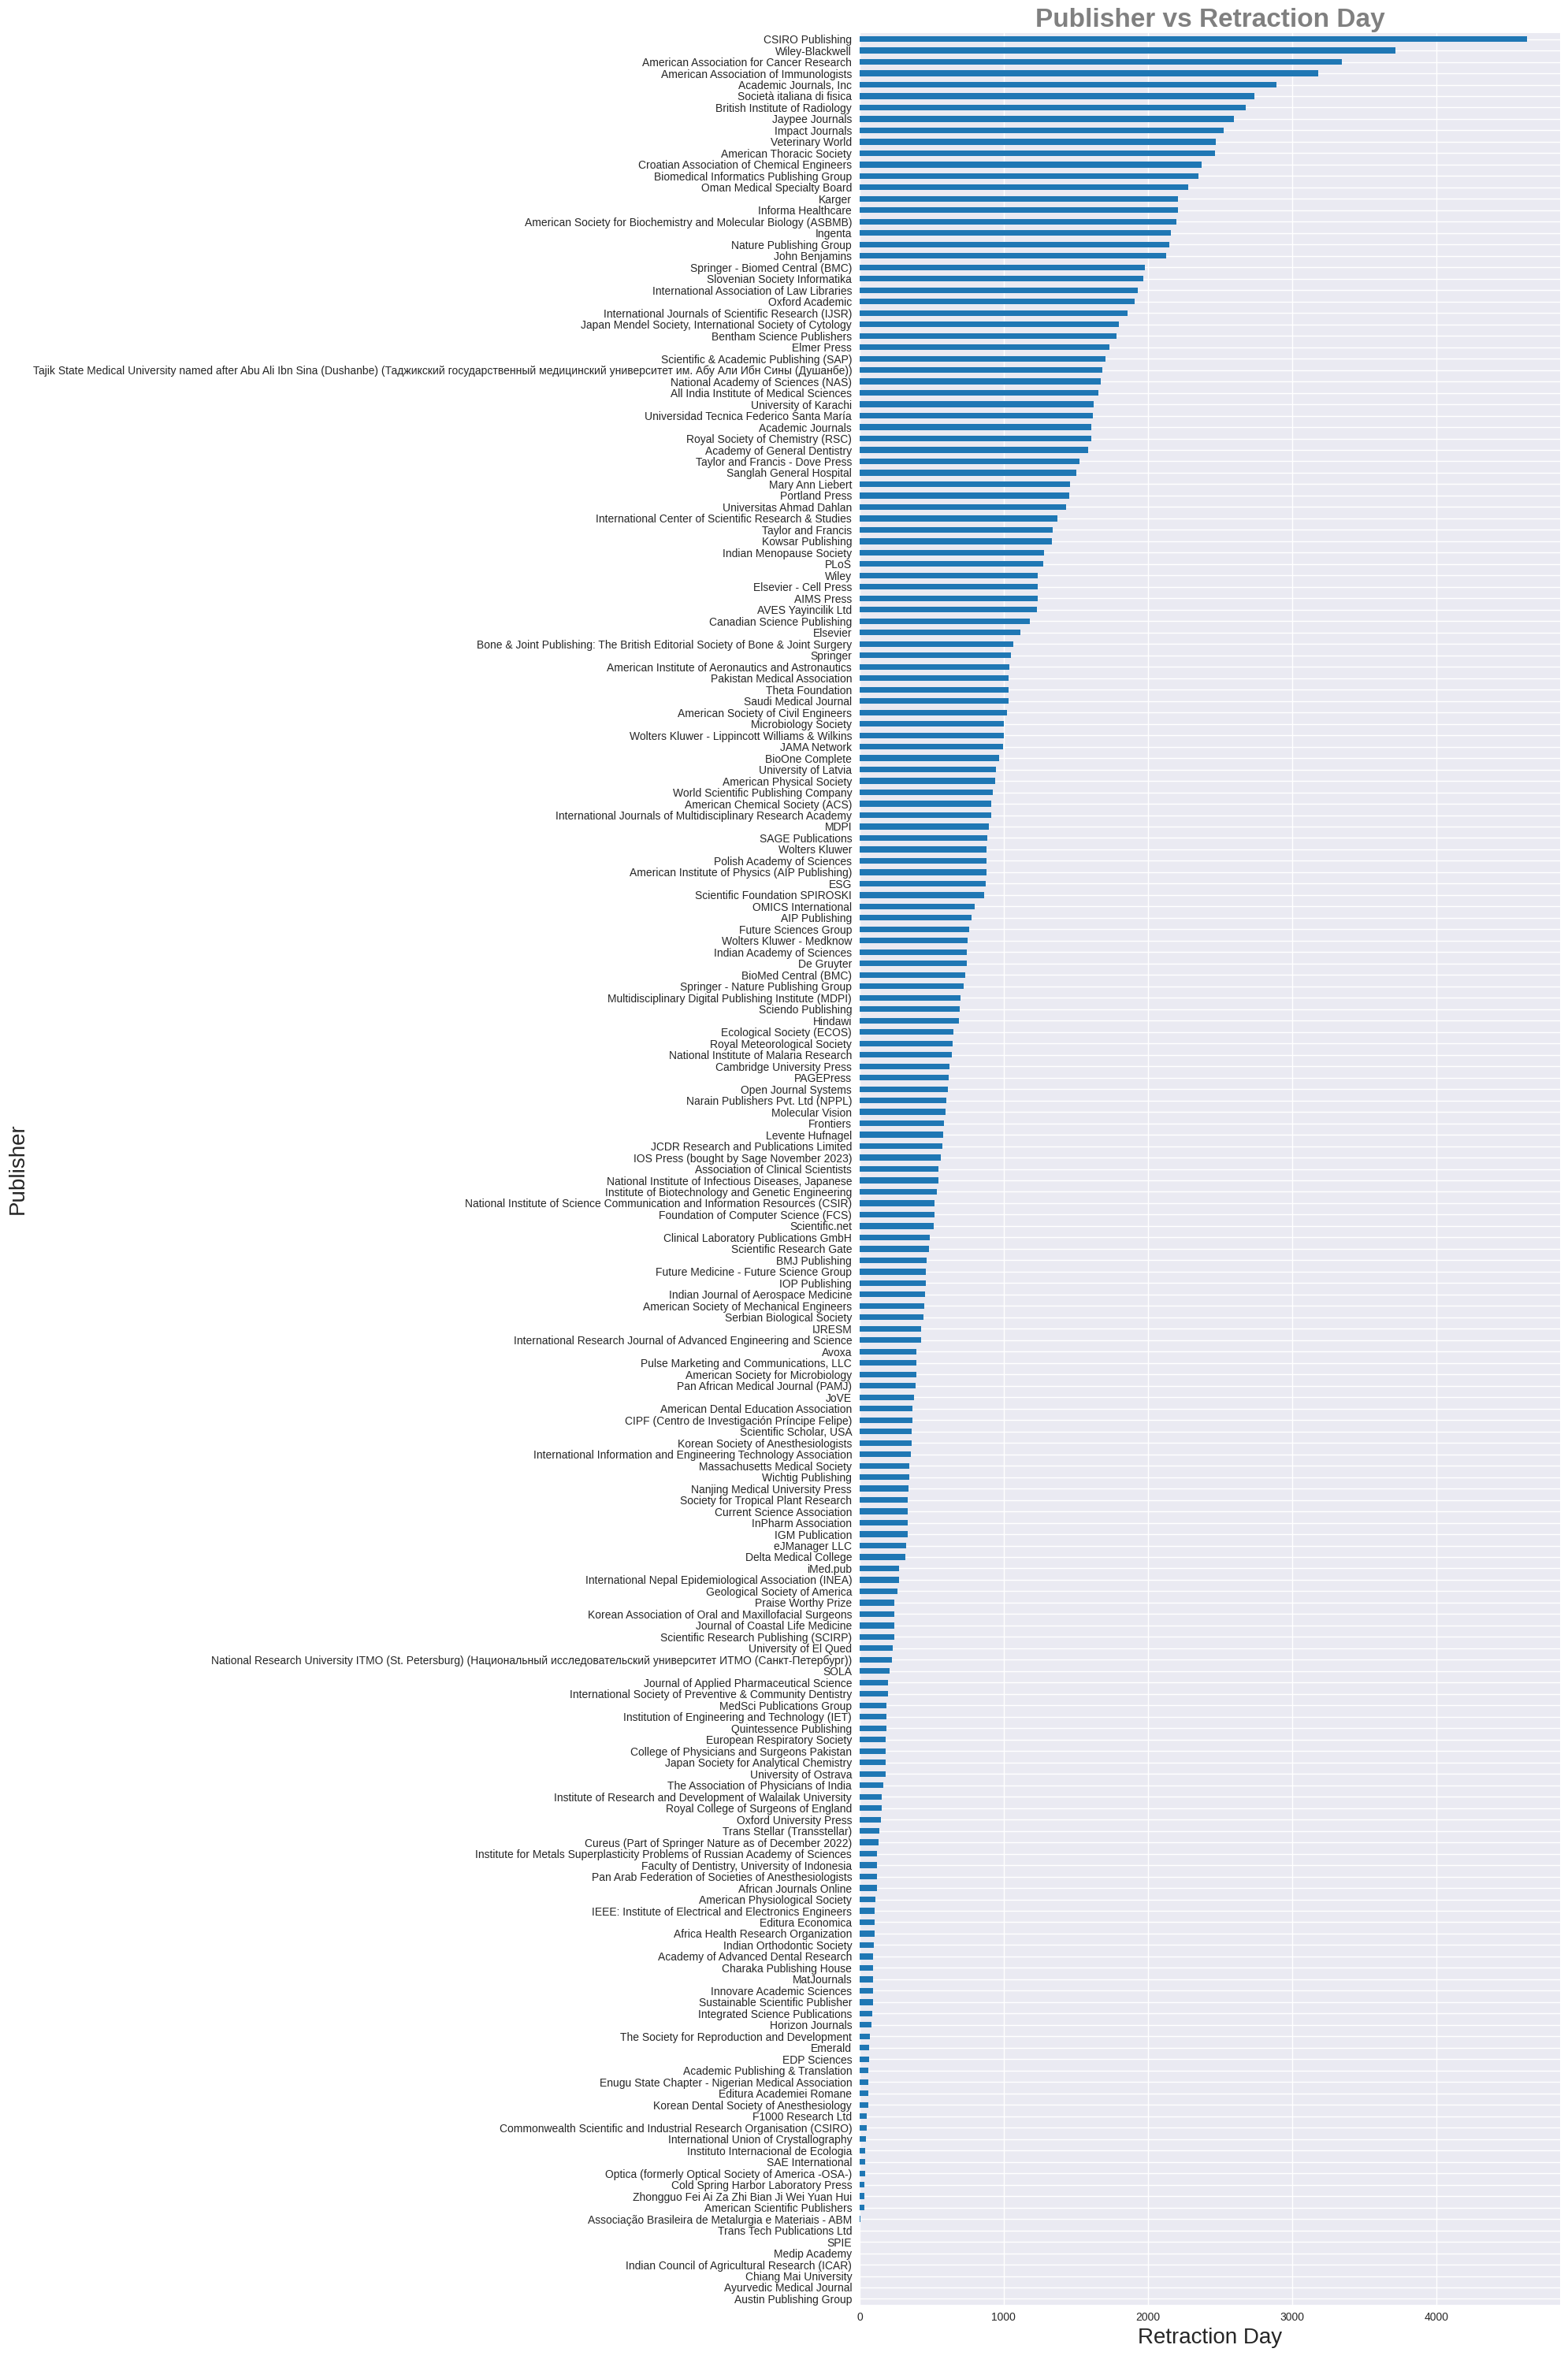

In [175]:
IdfP.groupby("Publisher")["RetractionTime"].mean().sort_values().plot(kind="barh",figsize=(20,30))
plt.title("Publisher vs Retraction Day",fontsize=24,weight="bold",color="Gray")
plt.yticks(rotation=0,fontsize=10)
plt.ylabel("Publisher",fontsize=20)
plt.xlabel("Retraction Day",fontsize=20)
plt.tight_layout()

Text(0, 0.5, 'Retraction Day')

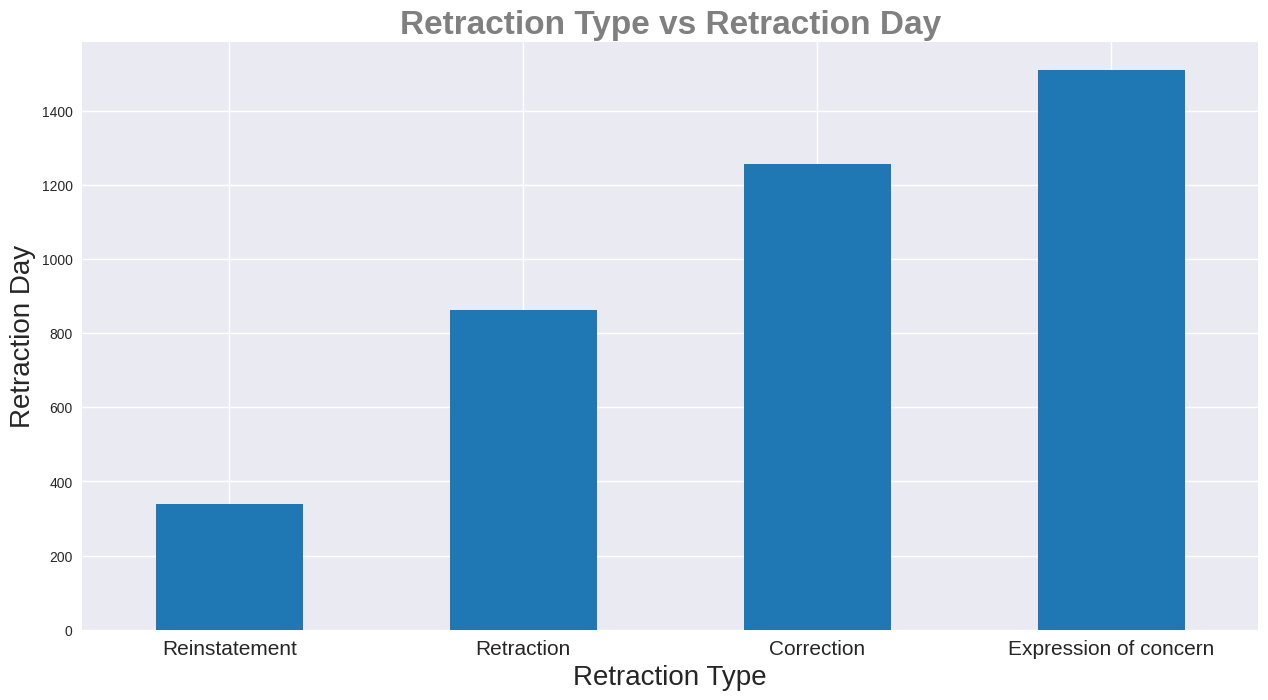

In [176]:

IdfRT.groupby("RetractionNature")["RetractionTime"].mean().sort_values().plot(kind="bar",figsize=(12,6))
plt.title("Retraction Type vs Retraction Day",fontsize=24,weight="bold",color="Gray")
plt.xticks(rotation=0,fontsize=15)

plt.xlabel("Retraction Type",fontsize=20)
plt.ylabel("Retraction Day",fontsize=20)



#Global Retraction Landscape:

China leads globally in the number of retractions, accounting for approximately 43% of all retractions in the dataset. This is followed by the United States and then India. The top 10 countries contribute to a significant 75.7% of all retractions, indicating a concentration of the issue.
'Investigation by Journal/Publisher' and 'Unreliable Results' are the most common global reasons for retraction, suggesting widespread issues in research validation and publication ethics.
'Research Article' is the most frequently retracted article type globally.
Indian Retraction Landscape (Detailed Analysis):

**High-Risk Subjects**: In India, Computer Science, Technology, Biochemistry, and Materials Science are particularly prone to retractions, making up nearly 30% of all known retractions from the country. This highlights a need for targeted ethical training and rigorous review processes in these fields.


**Transparency Concerns**: A significant portion of retractions from India lack critical information. Approximately 18% of retracted papers do not specify an institution, and 4265 papers (a large number within the Indian context) do not have a stated reason for retraction or article type. This data opacity impedes efforts to address root causes effectively.


**Leading Publishers**: Springer, Hindawi, and Elsevier are the publishers with the highest number of retractions originating from India, suggesting they either publish a large volume of Indian research or face specific challenges in maintaining publication integrity for this region.


**Primary Reasons for Retraction in India**:

The top reasons for retractions in India largely mirror global trends but are intensified: 'Investigation by Journal/Publisher', 'Fake Peer Review', 'Unreliable Results', and 'Investigation by Third Party' collectively account for about 50% of the explained retractions. This indicates systemic issues such as peer review manipulation and data fabrication.


**Retraction Timelines**: 'Correction/Erratum/Corrigendum' and 'Retraction Notice' tend to have longer retraction periods, possibly due to the complexity of the investigation or remediation required.
Overall Implications:



The analysis underscores a critical need for enhanced research integrity globally, with a specific focus on India. Addressing the high incidence of retractions in certain disciplines, improving data transparency in reporting retractions, and collaborating with publishers to enforce stricter ethical guidelines are crucial steps. Strengthening oversight and promoting a culture of research ethics are essential to safeguard the credibility of scientific output.

**Implications for India:**

The findings underscore the urgent need for the Indian academic and governmental bodies to:

1.  **Strengthen Research Integrity**: Implement stricter guidelines and educational programs focused on research ethics, particularly in high-retraction fields like Computer Science and Technology.
2.  **Enhance Accountability**: Address the issue of unspecified institutions and reasons for retraction to ensure greater accountability and traceability.
3.  **Support Underrepresented Research Areas**: Encourage and provide platforms for subjects with fewer retractions (e.g., Journalism, History) to foster a more diverse and robust research ecosystem.
4.  **Collaborate with Publishers**: Work closely with major publishers to develop proactive mechanisms for identifying and preventing fraudulent practices like fake peer reviews and data fabrication.

Overall, improving research quality and ethical standards in India requires a multi-faceted approach involving policy changes, educational initiatives, and enhanced oversight across institutions and publishing platforms.




## Overall Insight into Retractions in India

The analysis reveals a significant issue with retractions in India, which ranks third globally after China and the United States. A closer look at the Indian context highlights several critical points:

*   **Dominant Subjects for Retractions**: The fields of **Computer Science, Technology, Biochemistry, and Materials Science** account for a substantial portion (nearly 30%) of known retractions in India. This indicates a concentrated problem within these disciplines, suggesting a need for increased vigilance and support to uphold research integrity.

*   **Data Transparency Issues**: A concerning number of retracted papers from India lack crucial metadata. Approximately **18% of retractions have no institution name mentioned**, and **4265 papers (a large proportion) do not specify a reason for retraction or article type**. This lack of transparency hinders effective identification and resolution of underlying problems in research.

*   **Leading Publishers and Article Types**: **Springer, Hindawi, and Elsevier** are the top publishers encountering retractions from India, with **Research Articles** being the most frequently retracted article type. This suggests that these publishers might be processing a high volume of submissions from these regions or that there are particular challenges in ensuring the quality of research articles within these domains.

*   **Primary Reasons for Retraction**: The most common reasons for retractions in India are **'Investigation by Journal/Publisher,' 'Fake Peer Review,' 'Unreliable Results,' and 'Investigation by Third Party,'** collectively accounting for roughly 50% of the retractions where a reason is stated. This points to systemic issues such as fraudulent review processes, data manipulation, or external investigations unearthing misconduct.

*   **Retraction Timelines**: 'Correction/Erratum/Corrigendum' and 'Retraction Notice' generally take the longest time to be retracted, while 'Meta-Analysis' and 'Guideline' types have shorter retraction periods. This variation might reflect the complexity of investigations or the nature of the errors involved in different article types.

**Implications for India:**

The findings underscore the urgent need for the Indian academic and governmental bodies to:

1.  **Strengthen Research Integrity**: Implement stricter guidelines and educational programs focused on research ethics, particularly in high-retraction fields like Computer Science and Technology.
2.  **Enhance Accountability**: Address the issue of unspecified institutions and reasons for retraction to ensure greater accountability and traceability.
3.  **Support Underrepresented Research Areas**: Encourage and provide platforms for subjects with fewer retractions (e.g., Journalism, History) to foster a more diverse and robust research ecosystem.
4.  **Collaborate with Publishers**: Work closely with major publishers to develop proactive mechanisms for identifying and preventing fraudulent practices like fake peer reviews and data fabrication.

Overall, improving research quality and ethical standards in India requires a multi-faceted approach involving policy changes, educational initiatives, and enhanced oversight across institutions and publishing platforms.